In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import tight_layout

In [3]:
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_2'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_klow'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_khigh'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_ksuper_high'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_ksuper_low'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/red_ksuper_low_1E8'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/red_ksuper_low_2'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/.DS_Store')]

In [7]:
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)
scenario_name = "red_ksuper_low_2"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
df = pd.read_csv(os.path.join(post_path, 'parameters_best_0.csv'))
range_real = [0, 1, 3, 4, 6, 7, 9, 10, 11, 12, 13]
range_alive = [1, 4, 9, 10, 11, 12, 13]
range_dead = [0, 3, 6, 7]

In [8]:
df_dead_list = []
for id in range_dead:
    df =pd.read_csv(os.path.join(post_path,f'parameters_best_{id}.csv')).sort_values(by=[f't{id}'])
    df.reset_index(inplace=True)
    df_dead_list.append(df)
df_alive = pd.read_csv(os.path.join(post_path,f'parameters_best_mean_alive.csv')).sort_values(by=['alive_mean'])
df_alive.reset_index(inplace=True)

In [9]:
variables = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta', 'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation','g_bark' ]

In [10]:
dfs = df_dead_list[3][variables][0:1000]
#dfs = df_alive[variables][0:1000]

In [11]:
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score


In [12]:
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto')
kmeans.fit(dfs)

KMeans(n_clusters=3, random_state=0)

<Axes: ylabel='stem_hydraulic_capacitance'>

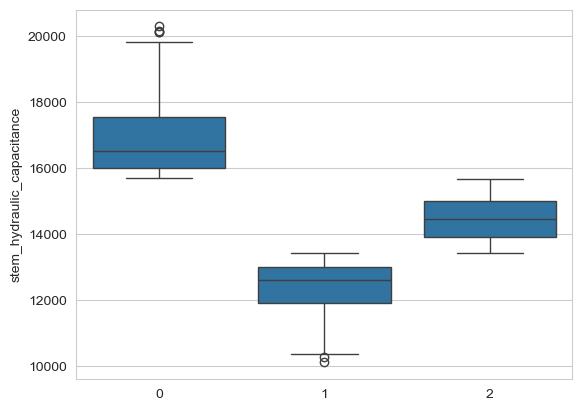

In [13]:
sns.boxplot(x = kmeans.labels_, y = dfs['stem_hydraulic_capacitance'])


In [14]:
K = range(2, 12)
fits = []
score = []

for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(dfs)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(dfs, model.labels_, metric='euclidean'))

<Axes: >

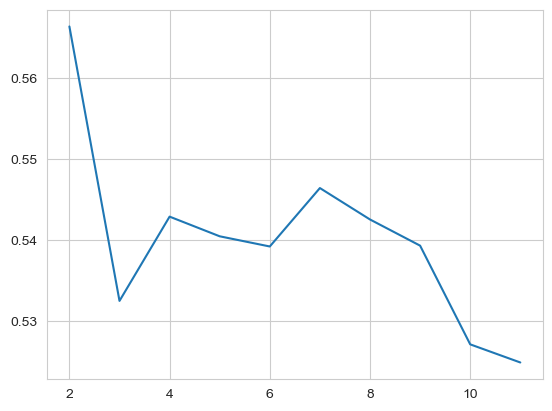

In [15]:
sns.lineplot(x = K, y = score)

In [16]:
kmeans = KMeans(n_clusters = 7, random_state = 0, n_init='auto')
kmeans.fit(dfs)

KMeans(n_clusters=7, random_state=0)

In [17]:
len(variables)

17

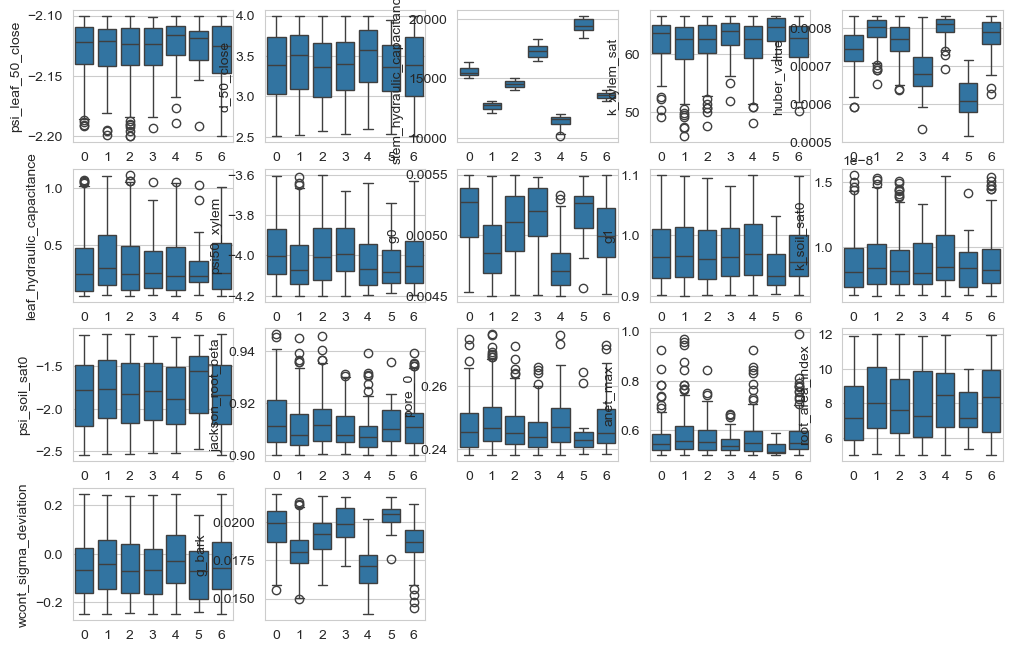

In [18]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(variables)+1), variables):
    ax = fig.add_subplot(5,5, index)
    sns.boxplot(x = kmeans.labels_, y = dfs[var], ax=ax)

<Axes: >

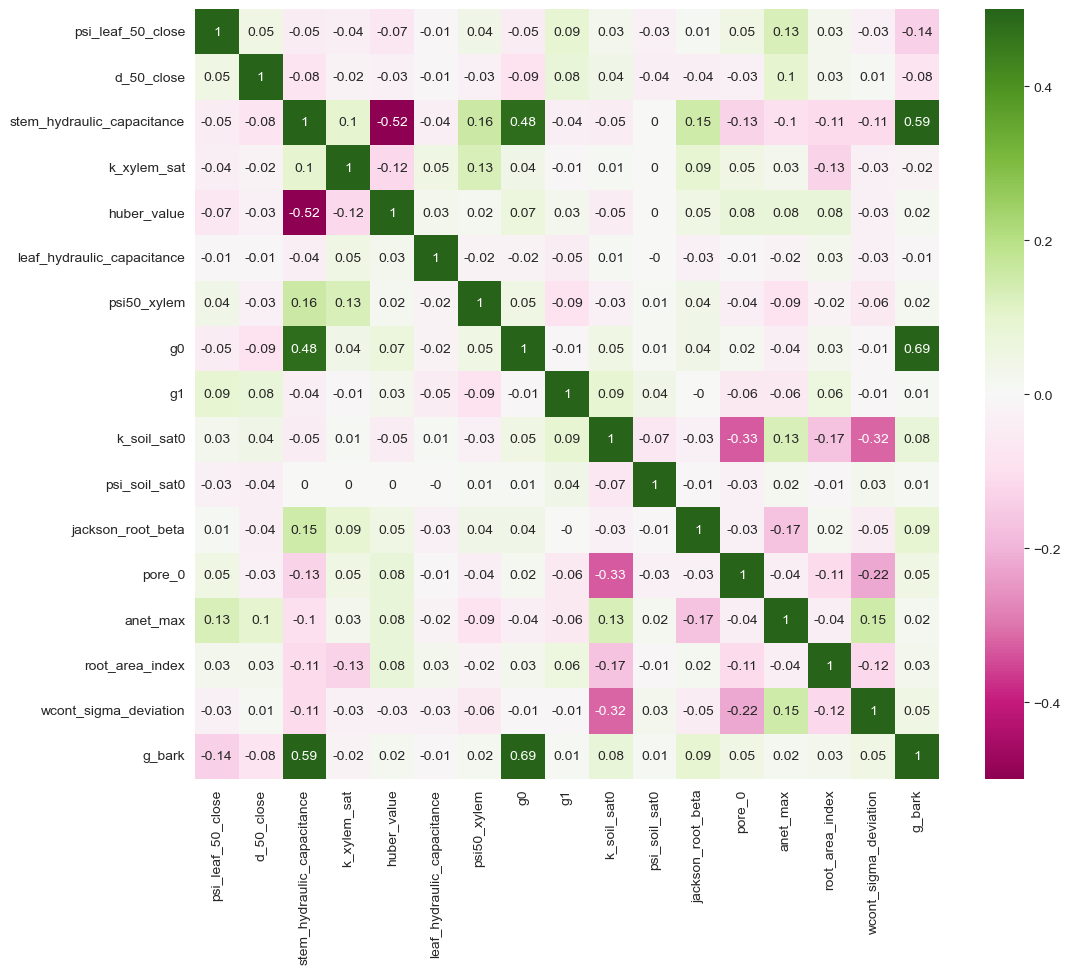

In [19]:
corr_matrix = dfs.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")

<Axes: ylabel='stem_hydraulic_capacitance'>

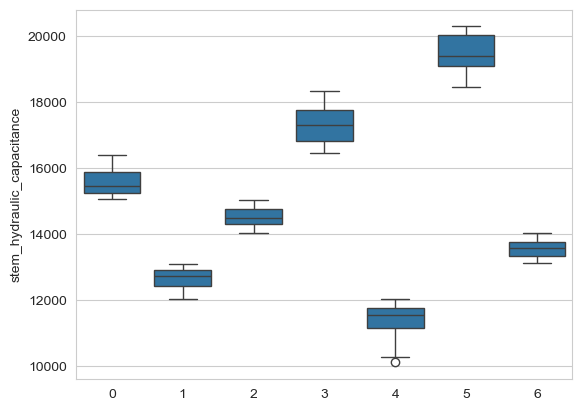

In [20]:
sns.boxplot(x = kmeans.labels_, y = dfs['stem_hydraulic_capacitance'])

<Axes: ylabel='huber_value'>

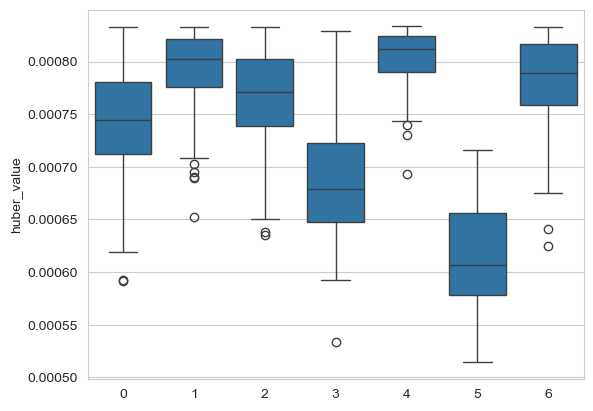

In [21]:
sns.boxplot(x = kmeans.labels_, y = dfs['huber_value'])

<Axes: ylabel='leaf_hydraulic_capacitance'>

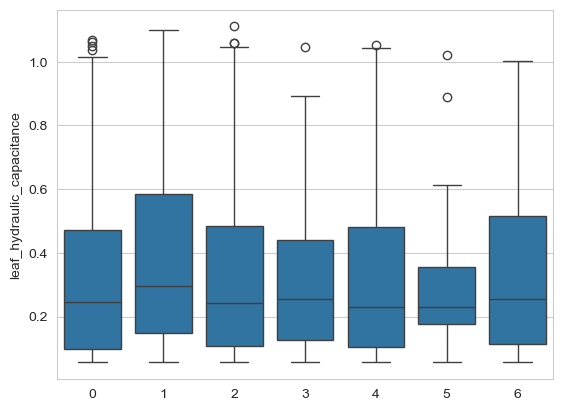

In [22]:
sns.boxplot(x=kmeans.labels_, y=dfs['leaf_hydraulic_capacitance'])

In [81]:
dfd0 = df_dead_list[0][variables][0:60000:40]
dfd0['alive'] = 0
dfd1 = df_dead_list[1][variables][0:60000:40]
dfd1['alive'] = 0
dfd2 = df_dead_list[2][variables][0:60000:40]
dfd2['alive'] = 0
dfd3 = df_dead_list[3][variables][0:60000:40]
dfd3['alive'] = 0
dfa = df_alive[variables][0:60000:10]
dfa['alive'] = 1
dfcs = pd.concat([dfd0,dfd1,dfd2, dfa], axis = 0)
dfc = dfcs.drop(['alive'], axis = 1)
dfc=(dfc-dfc.mean())/dfc.std()

In [82]:
dfc

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
0,1.406364,0.416884,-1.802112,1.490844,0.355770,-0.935822,1.290442,0.738368,-0.237012,-0.831834,1.410139,-0.944670,-0.944323,-1.006314,-1.313482,-0.352197,1.382488
40,0.913842,-0.852542,-1.841883,1.057154,0.186698,-0.549775,0.709797,-0.812447,-1.272048,-0.929266,-1.197480,-1.136943,-1.536846,-0.966015,-0.542586,-0.519363,0.489028
80,-0.367372,1.178843,-1.543008,0.553487,1.014499,1.797343,-0.045454,1.856186,0.402964,-1.279666,1.136996,-0.490504,-0.497304,-0.995111,0.731279,-1.737490,2.714914
120,-0.452657,-1.446885,-1.932101,1.355661,0.845315,-0.828477,0.985779,1.840227,-1.050786,-0.375782,0.617441,-1.226641,-1.090407,-0.883974,1.243548,-1.330007,2.274815
160,1.241600,0.393378,-1.072860,1.202668,-0.253510,-0.538217,-0.158222,0.888399,-1.337749,-1.489019,-0.170473,-1.083838,-1.944899,-0.968022,-1.399163,0.305238,1.057285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51150,-0.913739,-1.307004,0.707942,-0.651049,-0.335713,1.545942,-0.526242,-1.246195,0.520170,0.507415,-0.465956,-0.477862,0.570590,0.508414,0.656287,0.996880,0.687916
51160,1.159736,-0.777910,-0.089522,-0.987890,-0.268751,-0.900763,-0.089822,0.069027,0.016549,1.094606,-1.546247,-1.044187,0.619809,1.811374,0.054055,0.839276,0.461898
51170,0.754661,-0.600179,-0.114054,-0.099387,0.756362,-0.138773,-0.779747,-1.032616,1.557428,0.201852,0.970247,2.044451,0.562457,0.499898,0.320977,1.035918,-0.856062
51180,0.806233,-1.536671,0.244391,-1.446918,0.947298,0.009530,1.456875,-1.178864,-1.106958,0.677394,1.347407,-0.241624,0.547956,0.057039,-1.836162,0.269967,-1.184627


In [83]:
K = range(2, 12)
fits = []
score = []


for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(dfc)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(dfc, model.labels_, metric='euclidean'))

<Axes: >

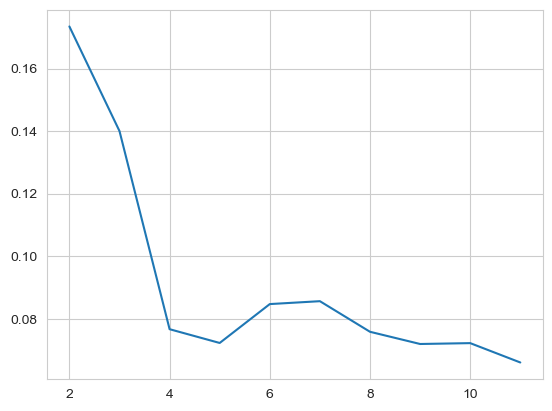

In [84]:
sns.lineplot(x = K, y = score)

In [85]:
nclusters = 5
kmeans = KMeans(n_clusters = nclusters, random_state = 0, n_init='auto')
kmeans.fit(dfc)

KMeans(n_clusters=5, random_state=0)

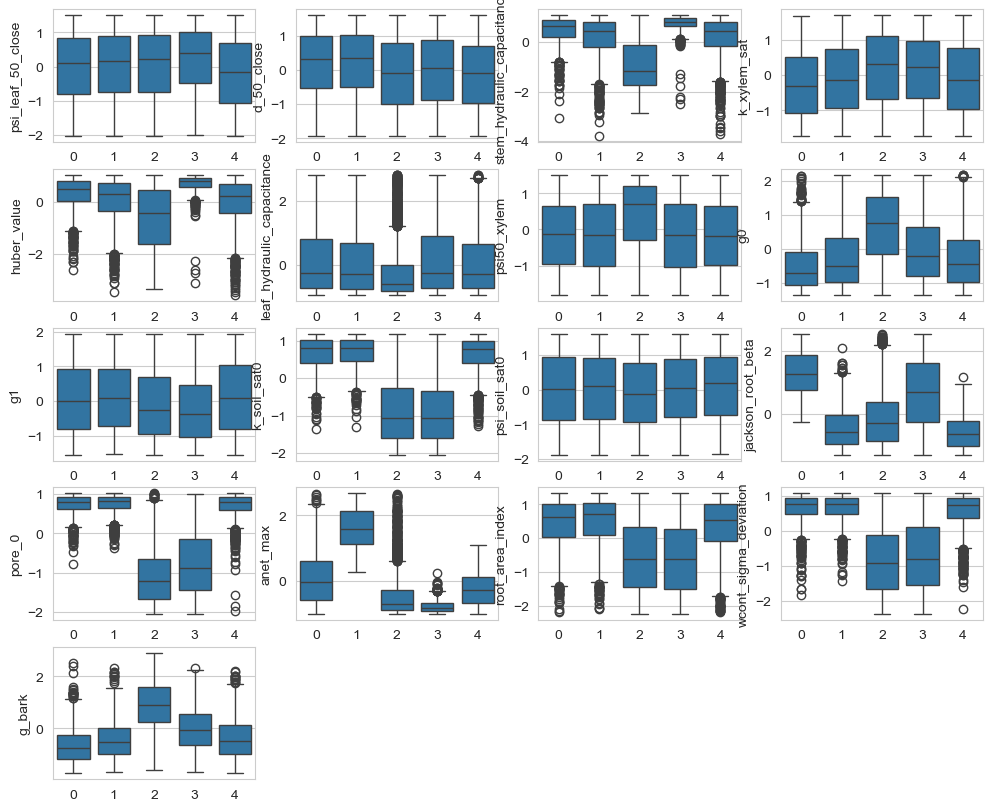

In [86]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(variables)+1), variables):
    ax = fig.add_subplot(5,4, index)
    sns.boxplot(x = kmeans.labels_, y = dfc[var], ax=ax)

In [87]:
 alive_means = [dfcs.loc[kmeans.labels_ == i, 'alive'].mean() for i in range(nclusters)]
 alive_means

[1.0, 1.0, 0.0, 0.0031128404669260703, 0.998676081200353]

In [88]:
import matplotlib.colors

In [89]:
cvals  = [0.0,  1]
colors = ["red","tab:blue"]

norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

In [109]:
labs = variables
labs.remove('psi_soil_sat0')


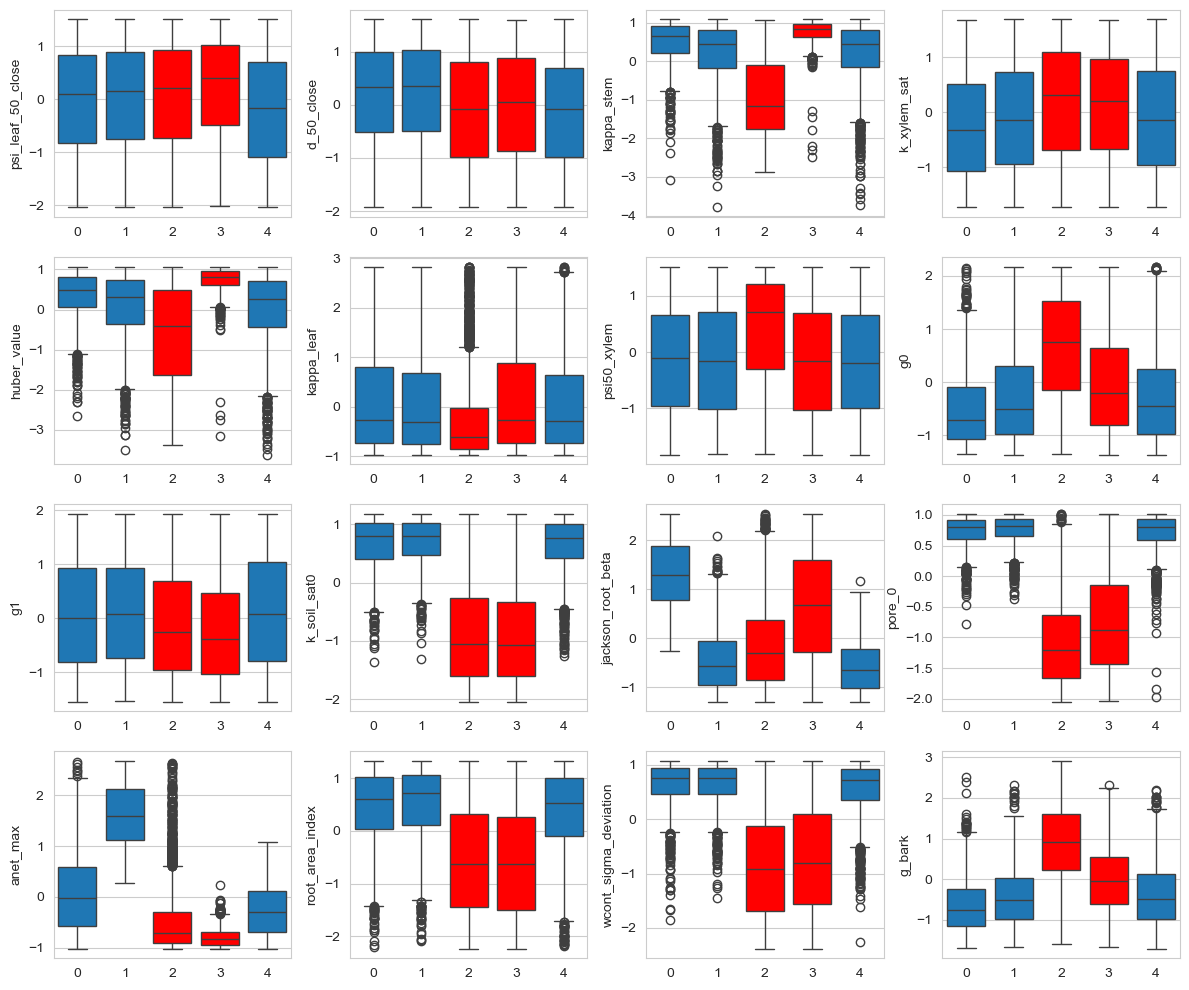

In [110]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(labs)+1), labs):
    ax = fig.add_subplot(4,4, index)
    sns.boxplot(x = kmeans.labels_, y = dfc[var], ax=ax)
    for i in range(nclusters):
        box = ax.patches[i]
        box.set_facecolor(cmap(alive_means[i]))
    if var =='stem_hydraulic_capacitance':
        var = 'kappa_stem'
    elif var =='leaf_hydraulic_capacitance':
        var = 'kappa_leaf'
    else:  
        var = var
    ax.set_ylabel(var)
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.savefig(os.path.join("plt","Classes.png"), dpi=300)

<Axes: >

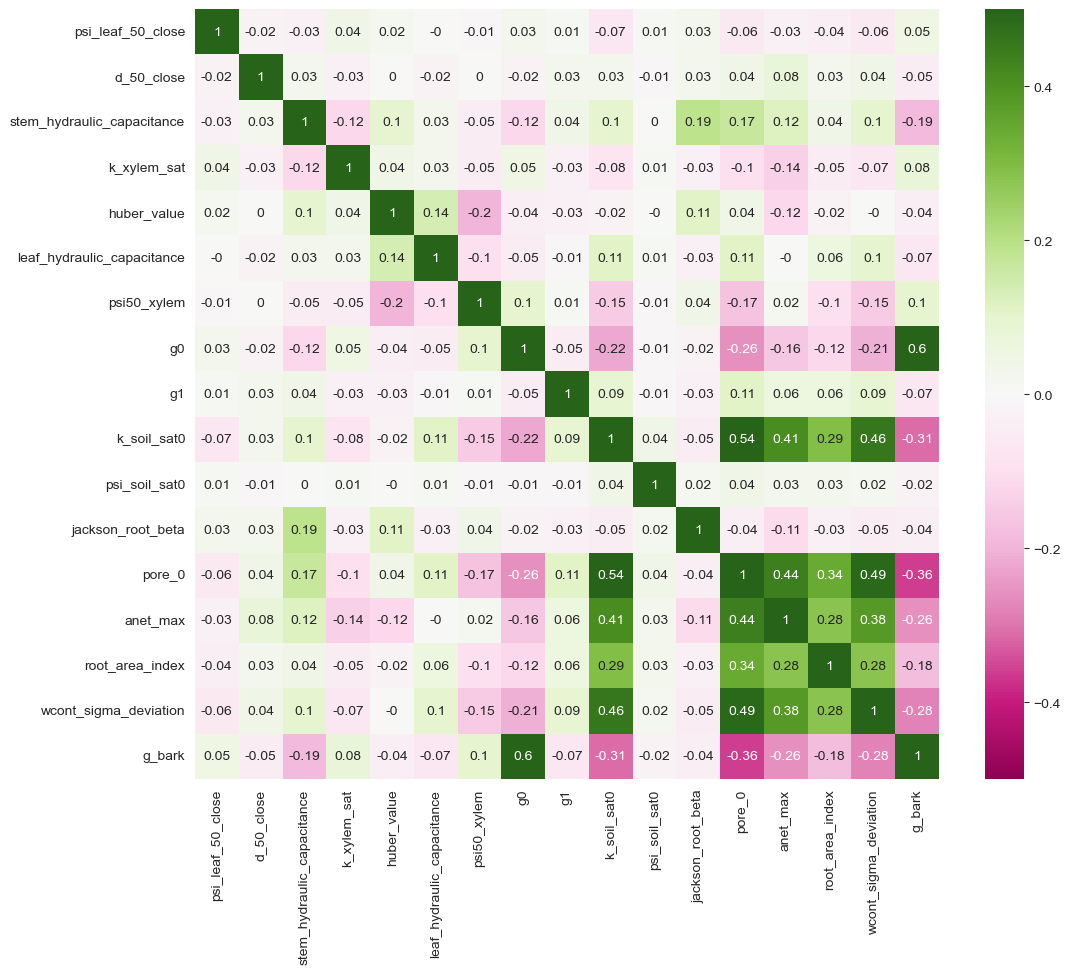

In [91]:
corr_matrix = dfc.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")

In [352]:
dfc

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
0,0.637490,0.485222,0.582615,0.970544,0.851068,-0.754838,-0.423109,-1.061931,1.103244,-1.098919,1.473648,-1.082830,-1.929913,-0.109541,0.004066,0.451160,0.233443
1,0.963511,0.900795,0.879732,1.344043,0.952321,-0.674049,-1.083421,-0.319214,-1.260245,0.150206,0.996921,-0.802646,-1.017888,-1.436323,0.530329,-1.811651,0.001674
2,0.865043,-0.475643,0.810215,1.182079,-0.111117,-0.019214,1.891453,-0.879912,-1.359854,-0.485485,1.611357,-1.143168,-2.197380,-1.292492,0.675691,0.001070,-0.589048
3,0.332099,-0.996789,0.493432,1.337814,0.874920,-0.546765,-0.312834,-0.331325,-1.730915,-1.059029,-0.785525,0.161646,-1.114471,-1.873708,-0.894599,-0.069965,-0.106838
4,1.418031,0.629636,-0.057303,1.005362,0.816562,-0.820273,-0.519772,-0.564454,1.431442,-0.960733,0.072854,-0.571149,-2.077510,-0.832831,0.234909,0.334253,-1.011326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.574822,-1.091520,0.731791,-1.429472,0.719122,0.655925,-0.702581,-0.179340,0.866328,1.738624,-0.013050,1.352069,0.521089,0.321755,-1.225140,0.770593,0.536259
996,0.921816,0.280187,-2.201942,-0.815835,-0.306473,-0.816686,-0.658531,2.511821,-0.981193,1.793172,-1.248769,1.840491,0.342422,0.167372,1.196235,1.090317,2.011952
997,1.649465,0.988282,-0.316736,-0.046245,-1.806215,-0.802728,-0.214220,-0.463716,0.173091,-0.891204,1.513633,-1.347145,0.858477,-0.152091,0.568167,0.843194,-0.238626
998,-1.223309,-0.638526,0.195456,-1.833345,-0.012449,-0.803387,-0.750055,-0.095800,-0.883714,-0.364897,-0.092798,0.464585,1.248805,0.448986,-1.700832,0.959646,0.784456


In [33]:
from sklearn.cluster import HDBSCAN
from sklearn import metrics

db = HDBSCAN(min_samples=5).fit(dfc)

labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(f"Silhouette Coefficient: {metrics.silhouette_score(dfc, db.labels_,metric='euclidean'):.3f}")

Estimated number of clusters: 2
Estimated number of noise points: 19
Silhouette Coefficient: 0.245


In [34]:
alive_means = [dfcs.loc[db.labels_ == i, 'alive'].mean() for i in range(n_clusters_)]
alive_means

[0.0, 1.0]

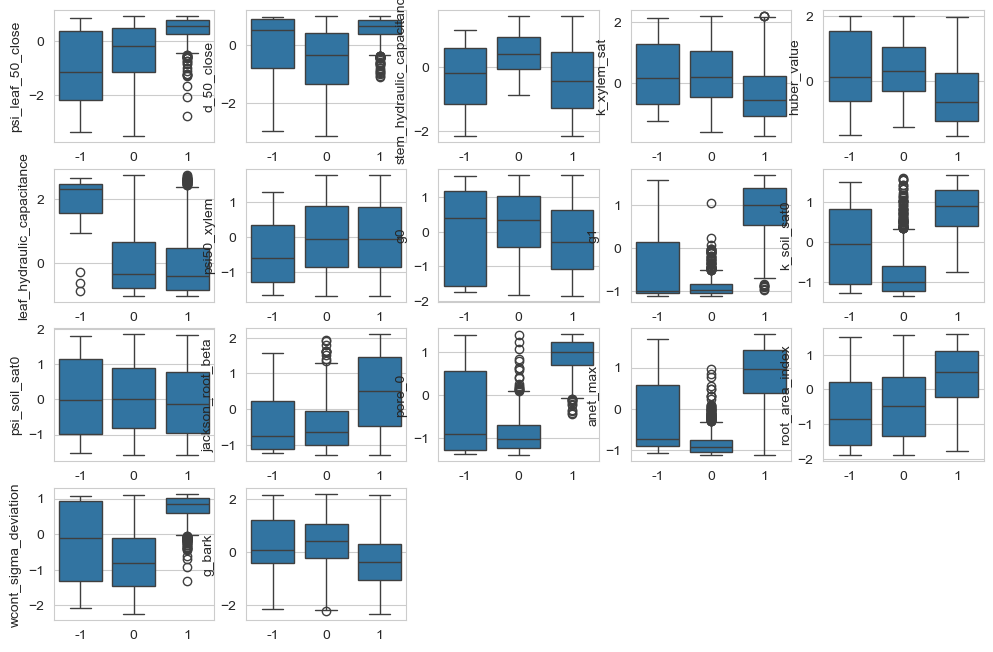

In [35]:
fig = plt.figure(figsize=(12, 10))
for index, var in zip(np.arange(1, len(variables) + 1), variables):
    ax = fig.add_subplot(5, 5, index)
    sns.boxplot(x=db.labels_, y=dfc[var], ax=ax)

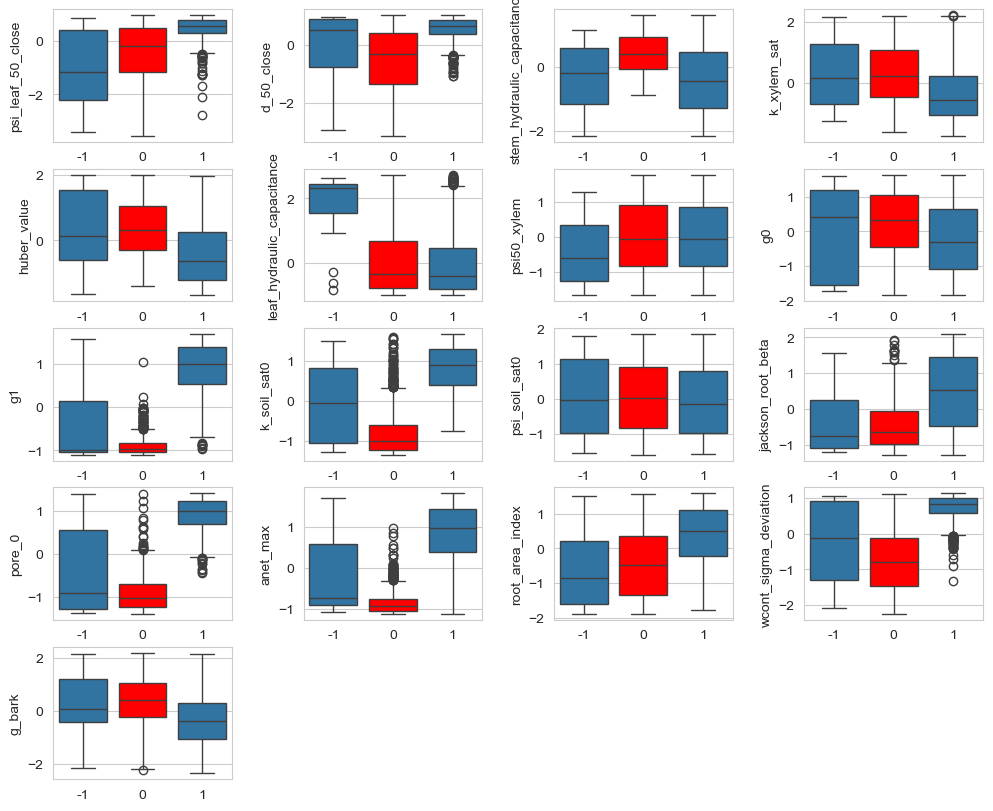

In [36]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(variables)+1), variables):
    ax = fig.add_subplot(5,4, index)
    sns.boxplot(x = db.labels_, y = dfc[var], ax=ax)
    for i in range(n_clusters_):
        box = ax.patches[i]
        if i > 0:
            box.set_facecolor(cmap(alive_means[i-1]))
plt.subplots_adjust(wspace=0.4)

In [313]:
# print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
# print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
# print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
# print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
# print(
#     "Adjusted Mutual Information:"
#     f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
# )


Silhouette Coefficient: 0.278
